# CDI IceChunk Store Viewer

This notebook demonstrates how to:
1. Open IceChunk stores from GCS
2. View 1km and 10km resolution CDI data
3. Plot the data on-the-fly

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import icechunk

# Configuration
SERVICE_ACCOUNT_FILE = "/scratch/notebook/coiled-data-e4drr_202505.json"
GCS_BUCKET = "cdi_arco"
GCS_PATH = "bn_icpac_cdi_store"

## Helper Functions

In [2]:
def open_icechunk_store(year, month_name, resolution="1km"):
    """
    Open an IceChunk store from GCS.
    
    Parameters:
    -----------
    year : int
        Year of the data (2011-2025)
    month_name : str
        Month name (e.g., 'jan', 'feb', 'mar', etc.)
    resolution : str
        Resolution of the data ('1km' or '10km')
    
    Returns:
    --------
    xarray.Dataset, icechunk.Repository
    """
    filename = f"eadw-cdi-data-{year}-{month_name}"
    
    if resolution == "1km":
        prefix = f"{GCS_PATH}/icechunk/{year}/{filename}"
    else:
        prefix = f"{GCS_PATH}/icechunk_10km/{year}/{filename}"
    
    print(f"Opening: gs://{GCS_BUCKET}/{prefix}")
    
    # Create GCS storage
    storage = icechunk.gcs_storage(
        bucket=GCS_BUCKET,
        prefix=prefix,
        service_account_file=SERVICE_ACCOUNT_FILE
    )
    
    # Open repository
    repo = icechunk.Repository.open(storage=storage)
    session = repo.readonly_session(branch='main')
    store = session.store
    
    # Open as xarray dataset
    ds = xr.open_zarr(store, consolidated=False)
    
    return ds, repo

## Example 1: Open and View 1km Dataset

In [3]:
# Open 1km resolution data for April 2011
ds_1km, repo_1km = open_icechunk_store(2011, "apr", "1km")

# Display dataset info
print("\n1km Dataset Info:")
print(f"  Dimensions: {dict(ds_1km.sizes)}")
print(f"  Variables: {list(ds_1km.data_vars)}")
print(f"  Coordinates: {list(ds_1km.coords)}")

ds_1km

Opening: gs://cdi_arco/bn_icpac_cdi_store/icechunk/2011/eadw-cdi-data-2011-apr

1km Dataset Info:
  Dimensions: {'y': 3480, 'x': 2950}
  Variables: ['spatial_ref', 'cdi']
  Coordinates: ['y', 'x']


<xarray.Dataset> Size: 82MB
Dimensions:      (y: 3480, x: 2950)
Coordinates:
  * y            (y) float64 28kB 23.1 23.09 23.08 ... -11.68 -11.68 -11.69
  * x            (x) float64 24kB 21.91 21.92 21.93 21.94 ... 51.38 51.39 51.4
Data variables:
    spatial_ref  int64 8B ...
    cdi          (y, x) float64 82MB dask.array<chunksize=(500, 500), meta=np.ndarray>
Attributes: (12/13)
    BBOX:              21.8, -11.8, 51.5, 23.2
    Source:            IGAD Climate Prediction and Applications Center (ICPAC)
    Website:           https://www.icpac.net
    Dataset:           Combined Drought Indicator (CDI)
    Indicator Info:    Combined Drought Indicator (CDI) integrates informatio...
    Data Use:          CDI is used to monitor both the onset of agricultural ...
    ...                ...
    Other Indicators:  https://droughtwatch.icpac.net/drought-indicators/
    Host System:       East Africa Drought Watch
    System URL:        https://droughtwatch.icpac.net/
    Attribution:       IGAD Climate Prediction and Applications Center (ICPAC)
    Licence:           CC BY 4.0 https://en.wikipedia.org/wiki/Creative_Commo...
    data_date:         2011-apr

In [4]:
# View commit history
print("Commit History:")
for snapshot in repo_1km.ancestry(branch='main'):
    print(f"  ID: {snapshot.id}")
    print(f"  Message: {snapshot.message}")
    print(f"  Written at: {snapshot.written_at}")
    print()

Commit History:
  ID: MFCSEJ76TP5F7796XAE0
  Message: Add 1km CDI data for 2011/eadw-cdi-data-2011-apr
  Written at: 2025-12-21 00:18:06.595601+00:00

  ID: 1CEE6R27H77GY609ND3G
  Message: Add 1km CDI data for 2011/eadw-cdi-data-2011-apr
  Written at: 2025-12-21 00:15:19.723358+00:00

  ID: AGY5NCSRT97HZZCQ35A0
  Message: Add 1km CDI data for 2011/eadw-cdi-data-2011-apr
  Written at: 2025-12-21 00:11:49.724087+00:00

  ID: 1CECHNKREP0F1RSTCMT0
  Message: Repository initialized
  Written at: 2025-12-21 00:11:48.518655+00:00



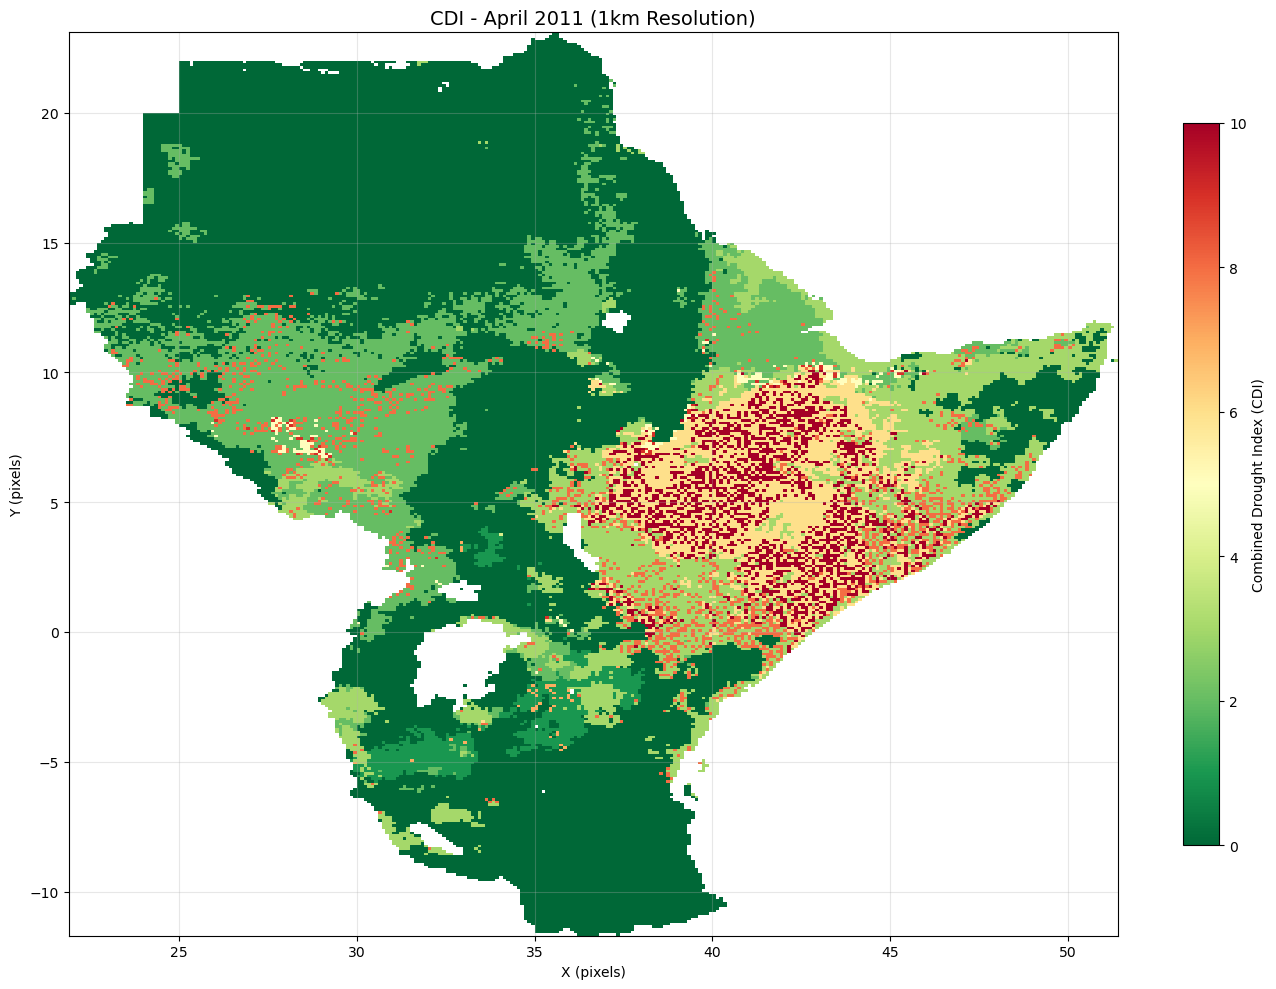

In [5]:
# Plot 1km CDI data
fig, ax = plt.subplots(figsize=(14, 10))

cdi = ds_1km['cdi'].squeeze()
cdi.plot(
    ax=ax,
    cmap='RdYlGn_r',
    robust=True,
    cbar_kwargs={'label': 'Combined Drought Index (CDI)', 'shrink': 0.8}
)

ax.set_title('CDI - April 2011 (1km Resolution)', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/notebook/cdi_2011_apr_1km.png', dpi=150, bbox_inches='tight')
plt.show()

## Example 2: Open and View 10km Dataset

In [6]:
# Open 10km resolution data for April 2011
ds_10km, repo_10km = open_icechunk_store(2011, "apr", "10km")

# Display dataset info
print("\n10km Dataset Info:")
print(f"  Dimensions: {dict(ds_10km.sizes)}")
print(f"  Variables: {list(ds_10km.data_vars)}")
print(f"  Coordinates: {list(ds_10km.coords)}")

ds_10km

Opening: gs://cdi_arco/bn_icpac_cdi_store/icechunk_10km/2011/eadw-cdi-data-2011-apr

10km Dataset Info:
  Dimensions: {'y': 348, 'x': 295}
  Variables: ['spatial_ref', 'cdi']
  Coordinates: ['y', 'x']


<xarray.Dataset> Size: 826kB
Dimensions:      (y: 348, x: 295)
Coordinates:
  * y            (y) float64 3kB 23.05 22.95 22.85 ... -11.45 -11.55 -11.65
  * x            (x) float64 2kB 21.95 22.05 22.15 22.25 ... 51.15 51.25 51.35
Data variables:
    spatial_ref  int64 8B ...
    cdi          (y, x) float64 821kB dask.array<chunksize=(174, 148), meta=np.ndarray>
Attributes: (12/13)
    BBOX:              21.8, -11.8, 51.5, 23.2
    Source:            IGAD Climate Prediction and Applications Center (ICPAC)
    Website:           https://www.icpac.net
    Dataset:           Combined Drought Indicator (CDI)
    Indicator Info:    Combined Drought Indicator (CDI) integrates informatio...
    Data Use:          CDI is used to monitor both the onset of agricultural ...
    ...                ...
    Other Indicators:  https://droughtwatch.icpac.net/drought-indicators/
    Host System:       East Africa Drought Watch
    System URL:        https://droughtwatch.icpac.net/
    Attribution:       IGAD Climate Prediction and Applications Center (ICPAC)
    Licence:           CC BY 4.0 https://en.wikipedia.org/wiki/Creative_Commo...
    data_date:         2011-apr

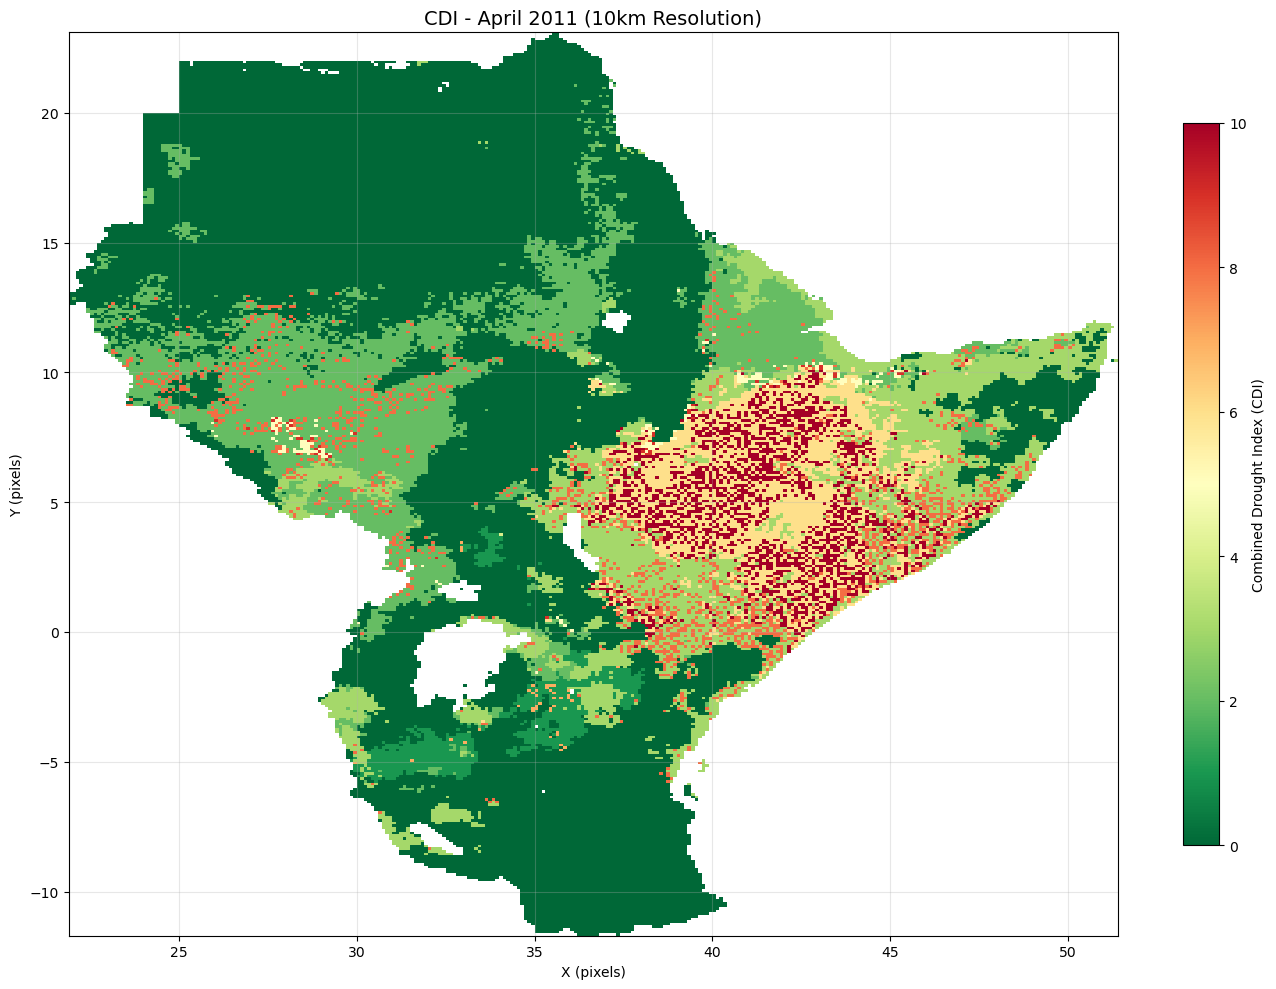

In [7]:
# Plot 10km CDI data
fig, ax = plt.subplots(figsize=(14, 10))

cdi_10km = ds_10km['cdi'].squeeze()
cdi_10km.plot(
    ax=ax,
    cmap='RdYlGn_r',
    robust=True,
    cbar_kwargs={'label': 'Combined Drought Index (CDI)', 'shrink': 0.8}
)

ax.set_title('CDI - April 2011 (10km Resolution)', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/notebook/cdi_2011_apr_10km.png', dpi=150, bbox_inches='tight')
plt.show()

## Example 3: Compare 1km vs 10km Side by Side

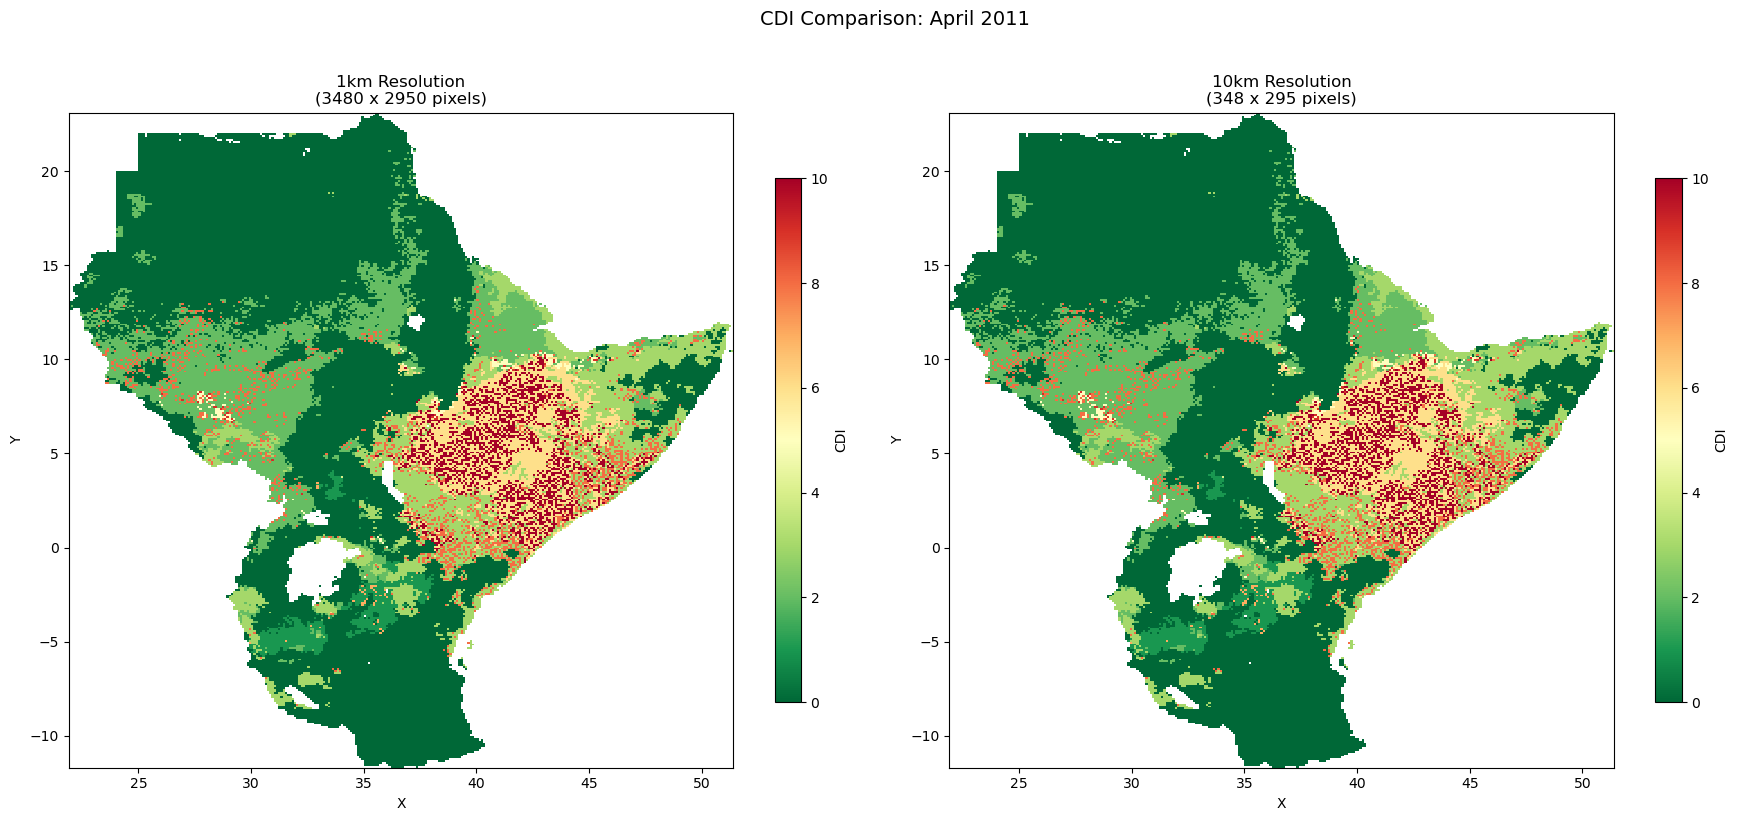

In [8]:
# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1km
ds_1km['cdi'].squeeze().plot(
    ax=axes[0],
    cmap='RdYlGn_r',
    robust=True,
    cbar_kwargs={'label': 'CDI', 'shrink': 0.8}
)
axes[0].set_title(f'1km Resolution\n({ds_1km.sizes["y"]} x {ds_1km.sizes["x"]} pixels)', fontsize=12)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Plot 10km
ds_10km['cdi'].squeeze().plot(
    ax=axes[1],
    cmap='RdYlGn_r',
    robust=True,
    cbar_kwargs={'label': 'CDI', 'shrink': 0.8}
)
axes[1].set_title(f'10km Resolution\n({ds_10km.sizes["y"]} x {ds_10km.sizes["x"]} pixels)', fontsize=12)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

plt.suptitle('CDI Comparison: April 2011', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/scratch/notebook/cdi_comparison_2011_apr.png', dpi=150, bbox_inches='tight')
plt.show()

## Example 4: View CDI Statistics

In [9]:
# Compute and display statistics
cdi_1km = ds_1km['cdi'].squeeze()
cdi_10km = ds_10km['cdi'].squeeze()

print("CDI Statistics Comparison:")
print("=" * 50)
print(f"{'Metric':<15} {'1km':>15} {'10km':>15}")
print("-" * 50)
print(f"{'Min':<15} {float(cdi_1km.min()):>15.4f} {float(cdi_10km.min()):>15.4f}")
print(f"{'Max':<15} {float(cdi_1km.max()):>15.4f} {float(cdi_10km.max()):>15.4f}")
print(f"{'Mean':<15} {float(cdi_1km.mean()):>15.4f} {float(cdi_10km.mean()):>15.4f}")
print(f"{'Std':<15} {float(cdi_1km.std()):>15.4f} {float(cdi_10km.std()):>15.4f}")
print(f"{'Median':<15} {float(cdi_1km.median()):>15.4f} {float(cdi_10km.median()):>15.4f}")

CDI Statistics Comparison:
Metric                      1km            10km
--------------------------------------------------
Min                      0.0000          0.0000
Max                     10.0000         10.0000
Mean                     1.8330          1.8330
Std                      2.7543          2.7543


NotImplementedError: The da.nanmedian function only works along an axis or a subset of axes.  The full algorithm is difficult to do in parallel

## Example 5: Interactive Month/Year Selection

In [10]:
def view_cdi(year, month, resolution="10km"):
    """
    Quick function to view CDI data for any month/year.
    
    Parameters:
    -----------
    year : int
        Year (2011-2025)
    month : str
        Month name (jan, feb, mar, apr, may, jun, jul, aug, sep, oct, nov, dec)
    resolution : str
        '1km' or '10km'
    """
    ds, repo = open_icechunk_store(year, month, resolution)
    
    fig, ax = plt.subplots(figsize=(12, 9))
    
    ds['cdi'].squeeze().plot(
        ax=ax,
        cmap='RdYlGn_r',
        robust=True,
        cbar_kwargs={'label': 'CDI', 'shrink': 0.8}
    )
    
    ax.set_title(f'CDI - {month.capitalize()} {year} ({resolution})', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    ds.close()
    return ds

In [ ]:
# Try different months - Change these values to view different data!
view_cdi(2011, "aug", "10km")

## Example 6: Download Data Locally

In [ ]:
def download_to_netcdf(year, month, resolution="10km", output_dir="/scratch/notebook"):
    """
    Download IceChunk data and save as NetCDF locally.
    
    Parameters:
    -----------
    year : int
        Year (2011-2025)
    month : str
        Month name
    resolution : str
        '1km' or '10km'
    output_dir : str
        Directory to save the file
    """
    ds, _ = open_icechunk_store(year, month, resolution)
    
    # Load data into memory
    ds_loaded = ds.compute()
    
    # Save as NetCDF
    output_path = f"{output_dir}/cdi_{year}_{month}_{resolution}.nc"
    ds_loaded.to_netcdf(output_path)
    
    print(f"Data saved to: {output_path}")
    
    ds.close()
    return output_path

In [ ]:
# Download April 2011 10km data as NetCDF
# Uncomment to run:
# download_to_netcdf(2011, "apr", "10km")

## Cleanup

In [ ]:
# Close datasets
ds_1km.close()
ds_10km.close()
print("Datasets closed.")